# 08 — Catálogo de algoritmos y evidencia comparativa

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

| Grupo benchmark | Instancia | Diferenciación esperada |
|-----------------|-----------|-------------------------|
| 3D-BPP | `showcase_3d_bpp_instance.json` | best_fit ~27 emp. vs extreme_points ~22 |
| Híbrido (misma instancia 3D) | `showcase_3d_bpp_instance.json` | compaction/LS mueven 8–11 piezas |
| Container Loading | `showcase_container_loading_instance.json` | weight_aware ~27 vs single_container ~17 |
| Single Container | `showcase_single_container_instance.json` | best_fit ~13 (94% util) vs first_fit ~16 |
| Cartonization | `showcase_cartonization_instance.json` | BOX_M (~49%) vs BOX_L (~21%) |

Catálogo de **12 algoritmos implementados** y **5 grupos de benchmark**, cada uno con su instancia showcase.


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from packing_services.algorithms.registry import get_default_registry
from packing_services.domain.enums import AlgorithmStatus
from _shared.loaders import BENCHMARK_GROUPS
import pandas as pd
from IPython.display import display as ipy_display

registry = get_default_registry()
impl = registry.list_metadata(status=AlgorithmStatus.IMPLEMENTED)
rows = [{'Algoritmo': m.name, 'Familia': m.algorithm_family.value,
         'Problemas': ', '.join(p.value for p in m.problem_types)} for m in impl]
ipy_display(pd.DataFrame(rows).style.hide(axis='index'))


Algoritmo,Familia,Problemas
best_box_volume_utilization,constructive_heuristic,CARTONIZATION
best_fit_decreasing_3d,constructive_heuristic,"3D_BPP, SINGLE_CONTAINER_LOADING"
constructive_plus_local_search,hybrid,"3D_BPP, CONTAINER_LOADING"
extreme_points_3d,constructive_heuristic,"3D_BPP, CONTAINER_LOADING"
first_fit_box,constructive_heuristic,CARTONIZATION
first_fit_decreasing_3d,constructive_heuristic,"3D_BPP, SINGLE_CONTAINER_LOADING"
heuristic_3d_bpp_v1,constructive_heuristic,"3D_BPP, SINGLE_CONTAINER_LOADING"
largest_feasible_box,constructive_heuristic,CARTONIZATION
single_container_constructive,constructive_heuristic,"SINGLE_CONTAINER_LOADING, CONTAINER_LOADING"
smallest_feasible_box,constructive_heuristic,CARTONIZATION


═══ Evidencia comparativa: 5 benchmarks homogéneos ═══
Motores comparables — 3D Bin Packing:


#,Algoritmo,Nombre,Opcional
1,heuristic_3d_bpp_v1,Volume First Candidate Placement,No
2,first_fit_decreasing_3d,First Fit Decreasing 3D,No
3,extreme_points_3d,Extreme Points Heuristic,No
4,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
5,py3dbp_adapter,py3dbp Adapter (baseline externo),Sí


Nota: best_fit ~27 emp. (85% util) vs extreme_points ~22 (66%)
Benchmark — 3D Bin Packing


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0582
2,first_fit_decreasing_3d,78.3%,25,5,Sí,0.0078
3,heuristic_3d_bpp_v1,78.3%,25,5,Sí,0.0085
4,py3dbp_adapter,78.3%,25,5,Sí,0.0154
5,extreme_points_3d,65.7%,22,8,Sí,0.0259


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


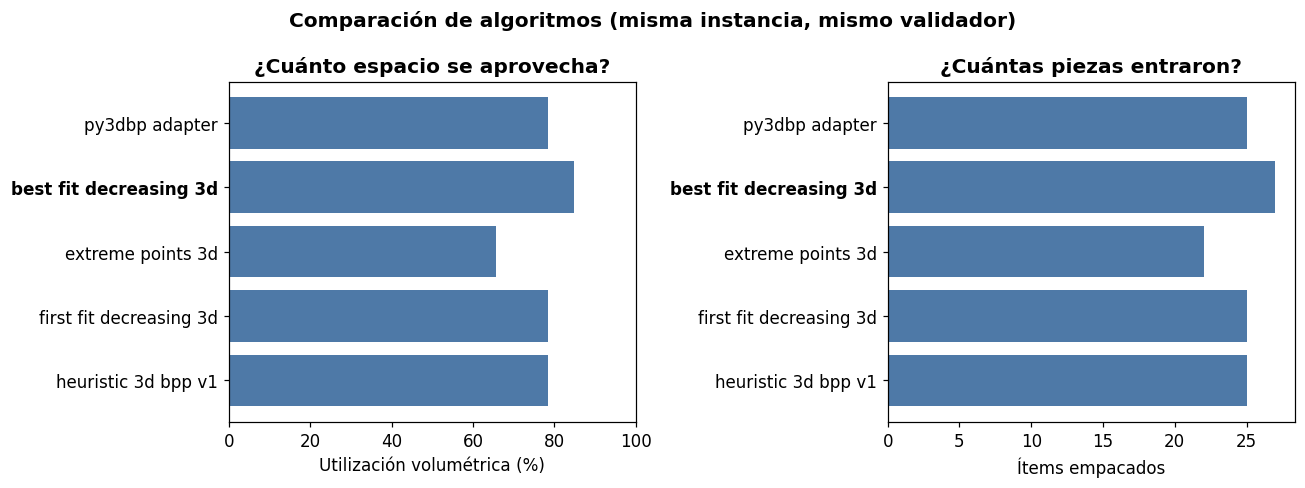

Motores comparables — 3D Bin Packing — Constructivo + mejora local:


#,Algoritmo,Nombre,Opcional
1,best_fit_decreasing_3d,Best Fit Decreasing 3D (baseline),No
2,solution_compaction,Compaction (mejora local),No
3,constructive_plus_local_search,Constructive + Local Improvement,No


Nota: misma cantidad empacada; compaction/LS mueven 8–11 piezas


Benchmark — 3D Bin Packing — Constructivo + mejora local


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Piezas movidas
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0343,nan
2,solution_compaction,84.8%,27,3,Sí,0.1184,8.000000
3,constructive_plus_local_search,84.8%,27,3,Sí,0.2145,11.000000


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


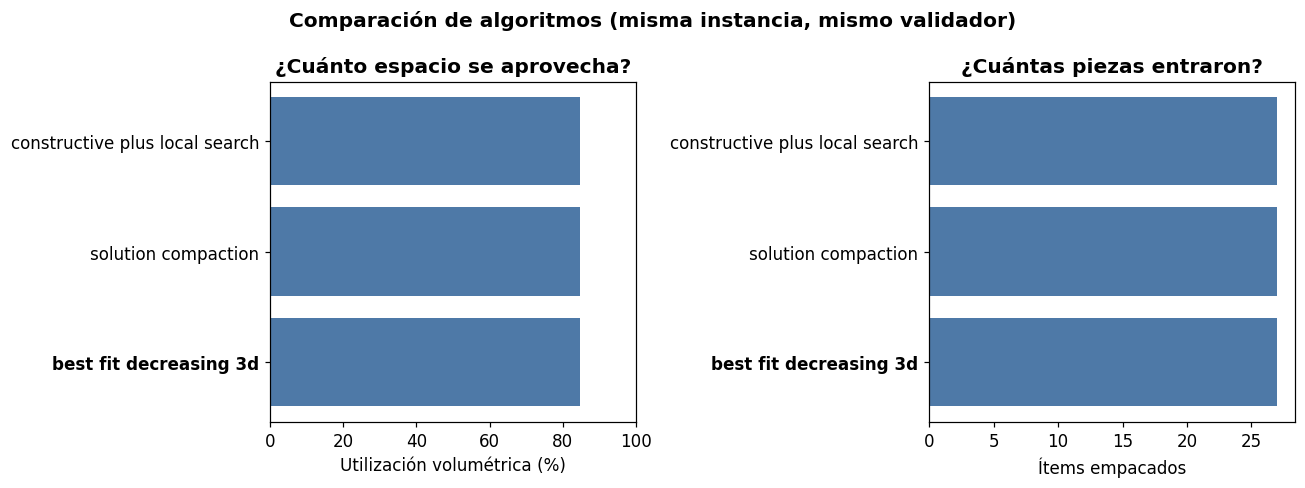

Motores comparables — Container Loading:


#,Algoritmo,Nombre,Opcional
1,single_container_constructive,Single Container Constructive,No
2,weight_aware_container_loading,Weight-aware Container Loading,No
3,extreme_points_3d,Extreme Points (multi-contenedor),No


2026-07-12 15:37:26,084 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=single_container_constructive items=30 containers=2


2026-07-12 15:37:26,099 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=weight_aware_container_loading items=30 containers=2


2026-07-12 15:37:26,134 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=extreme_points_3d items=30 containers=2


Nota: weight_aware ~27 emp. vs single_container ~17 (alta util) vs extreme_points ~22
Benchmark — Container Loading


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,weight_aware_container_loading,84.8%,27,3,Sí,0.0326
2,extreme_points_3d,65.7%,22,8,Sí,0.0166
3,single_container_constructive,87.5%,17,13,Sí,0.0131


Ranking Container Loading: (1) válidas; (2) menor items_unpacked; (3) mayor volume_utilization; (4) menor tiempo.


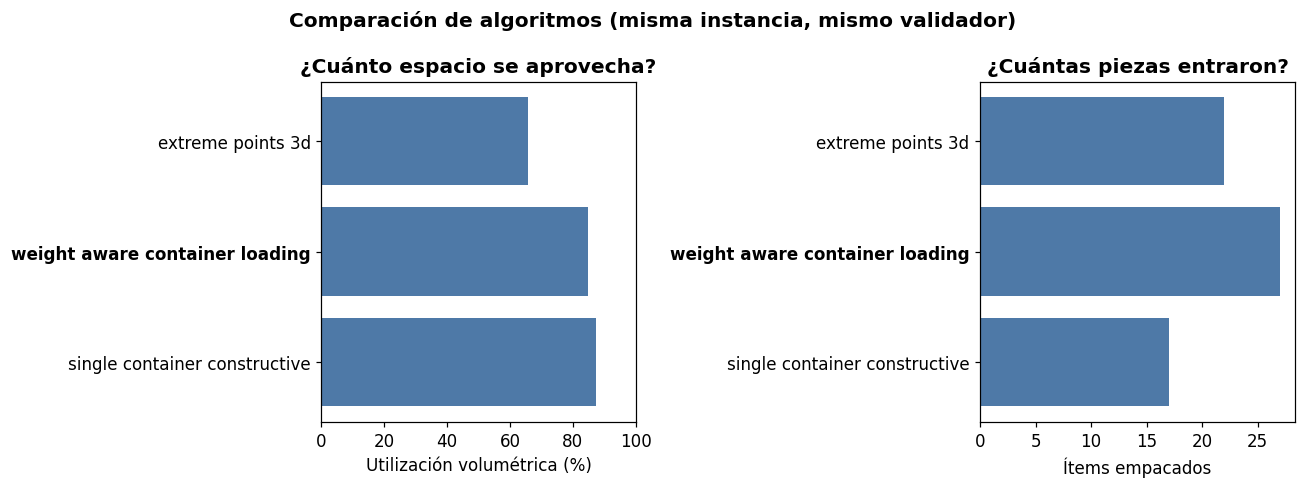

Motores comparables — Cartonization:


#,Algoritmo,Nombre,Opcional
1,smallest_feasible_box,Smallest Feasible Box,No
2,best_box_volume_utilization,Best Box by Volume Utilization,No
3,first_fit_box,First Fit Box (orden catálogo),No
4,largest_feasible_box,Largest Feasible Box,No


2026-07-12 15:37:26,390 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=smallest_feasible_box items=6 boxes=3


Nota: minimalistas → BOX_M (~49% util) vs largest_feasible → BOX_L (~21%)


2026-07-12 15:37:26,397 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=best_box_volume_utilization items=6 boxes=3


2026-07-12 15:37:26,405 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=first_fit_box items=6 boxes=3


2026-07-12 15:37:26,414 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=largest_feasible_box items=6 boxes=3


Benchmark — Cartonization


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Caja elegida
1,best_box_volume_utilization,48.5%,6,0,Sí,0.0029,BOX_M
2,smallest_feasible_box,48.5%,6,0,Sí,0.0031,BOX_M
3,first_fit_box,48.5%,6,0,Sí,0.0031,BOX_M
4,largest_feasible_box,20.8%,6,0,Sí,0.0042,BOX_L


Ranking Cartonization: (1) válidas; (2) todos los ítems empacados; (3) mayor volume_utilization; (4) menor tiempo.


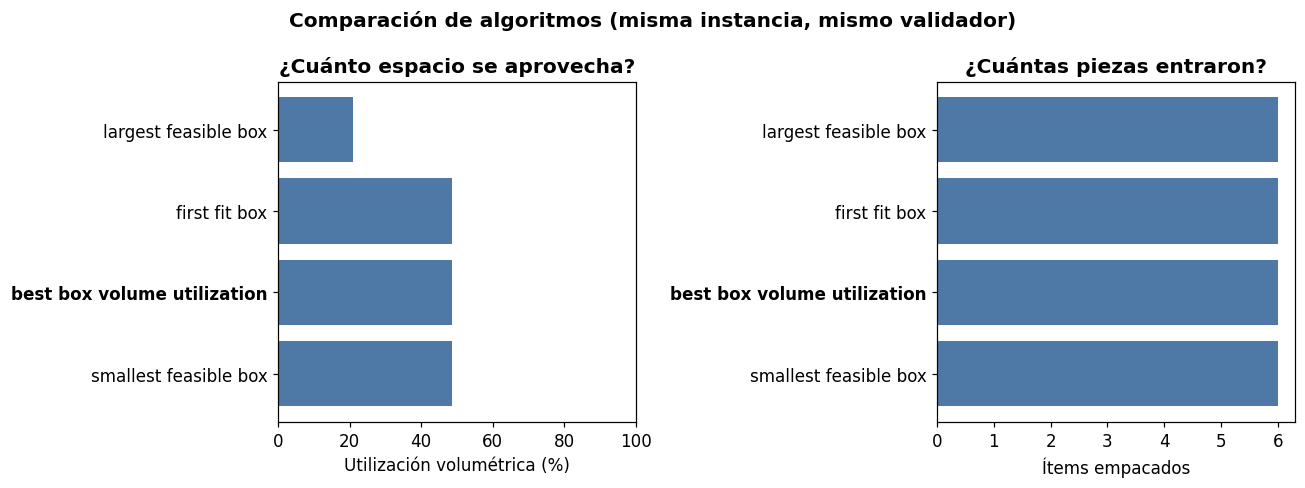

Motores comparables — Single Container Loading:


#,Algoritmo,Nombre,Opcional
1,single_container_constructive,Single Container Constructive,No
2,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
3,first_fit_decreasing_3d,First Fit Decreasing 3D,No


Nota: best_fit/single ~13 emp. (94% util) vs first_fit ~16 (89%)


Benchmark — Single Container Loading


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,single_container_constructive,94.3%,13,17,Sí,0.0118
2,best_fit_decreasing_3d,94.3%,13,17,Sí,0.0135
3,first_fit_decreasing_3d,89.3%,16,14,Sí,0.0050


Ranking Single Container Loading: (1) válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor tiempo.


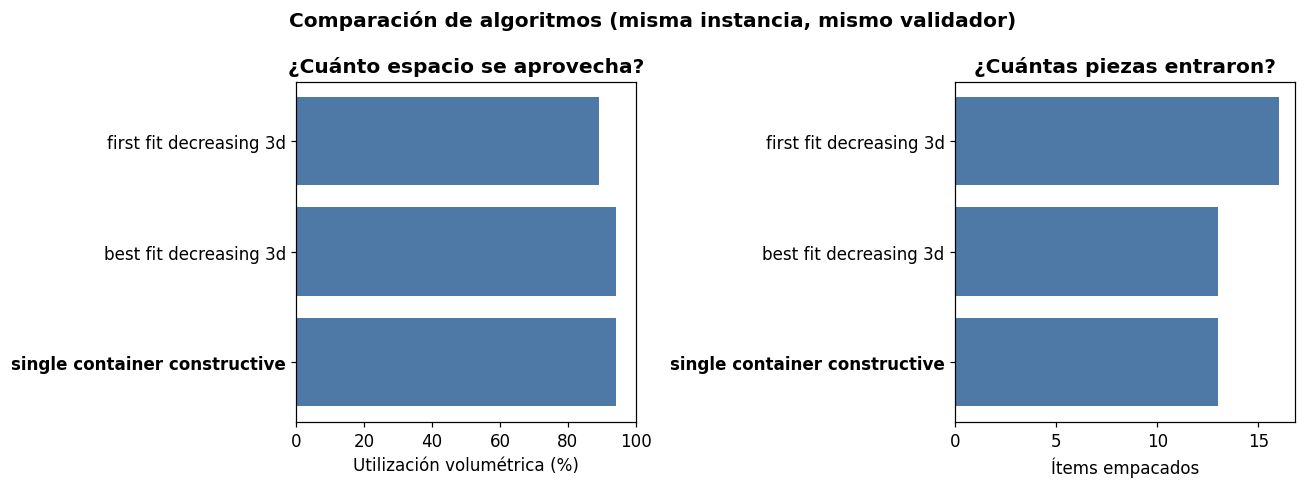

In [3]:
print('═══ Evidencia comparativa: 5 benchmarks homogéneos ═══')
for group in BENCHMARK_GROUPS:
    display.run_and_show_showcase_benchmark(group)


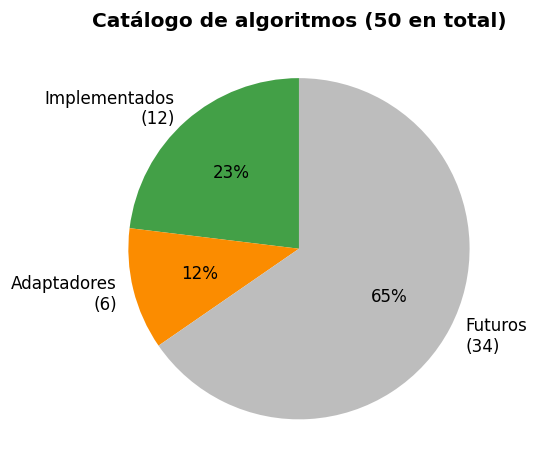

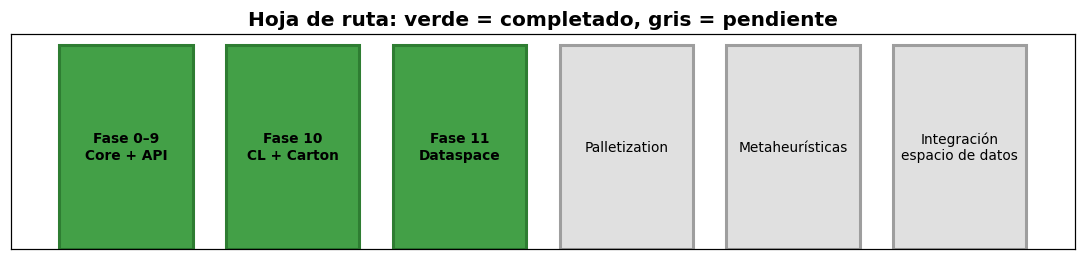

In [4]:
by = {}
for m in registry.list_metadata(): by[m.status.value] = by.get(m.status.value, 0) + 1
fig = viz.plot_algorithm_catalog_counts(by.get('implemented', 0), by.get('adapter', 0), by.get('future', 0))
plt.show()
fig = viz.plot_roadmap_phases(); plt.show()


**Siguiente:** `09_preparacion_espacio_de_datos.ipynb`
